In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split # Added for consistency

# --- Paths & Setup ---
DATA_DIR = "../data"
MODELS_DIR = "../models"
OUT_DIR = "../outputs"
METRICS_FILE = os.path.join(DATA_DIR, "comparison_metrics.json")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# --- Data Loading ---
X_old = pd.read_csv(os.path.join(DATA_DIR, "BTS2_encoded.csv")).values.astype(np.float32)
y_old = pd.read_csv(os.path.join(DATA_DIR, "BTS2_target.csv")).values.ravel()
X_new = pd.read_csv(os.path.join(DATA_DIR, "BTS1_encoded.csv")).values.astype(np.float32)
y_new = pd.read_csv(os.path.join(DATA_DIR, "BTS1_target.csv")).values.ravel()

# Label encoding (combined)
le = LabelEncoder()
le.fit(np.concatenate([y_old, y_new]))
y_old_enc = le.transform(y_old).astype(np.int64)
y_new_enc = le.transform(y_new).astype(np.int64)
num_classes = len(le.classes_)

# Split old data for test/validation
X_old_train, X_old_test, y_old_train, y_old_test = train_test_split(
    X_old, y_old_enc, test_size=0.2, stratify=y_old_enc, random_state=42
)

print("Loaded data shapes:")
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)
print("X_new:", X_new.shape, "y_new:", y_new_enc.shape)


# --- Model and Helper Functions ---
class MLP(nn.Module):
    # Using hidden_size=16 for consistency
    def __init__(self, input_dim, hidden_size=16, output_dim=None): 
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.fc_out = nn.Linear(hidden_size, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc_out(x)

def evaluate_acc(model, X, y):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32)
        yb = torch.tensor(y, dtype=torch.long)
        preds = torch.argmax(model(xb), dim=1)
        acc = (preds == yb).float().mean().item()
    return acc

def simple_train(model, X, y, optimizer, criterion, batch_size=128, epochs=1):
    model.train()
    n_samples = X.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuf = X[perm]
        y_shuf = y[perm]
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            xb = torch.tensor(X_shuf[start:end], dtype=torch.float32)
            yb = torch.tensor(y_shuf[start:end], dtype=torch.long)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    return model

def predict_proba_and_pred(model, X_np):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X_np, dtype=torch.float32)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).numpy()
        preds = np.argmax(probs, axis=1)
    return probs, preds


# --- Replay Buffer Class ---
class ReplayBuffer:
    def __init__(self, capacity, feature_dim):
        self.capacity = capacity
        self.memory_X = np.empty((0, feature_dim), dtype=np.float32)
        self.memory_y = np.empty((0,), dtype=np.int64)

    def push(self, X_batch, y_batch):
        # Combine existing memory and new samples
        combined_X = np.concatenate([self.memory_X, X_batch])
        combined_y = np.concatenate([self.memory_y, y_batch])
        
        # Sample down to capacity if needed (reservoir sampling logic)
        if len(combined_X) > self.capacity:
            indices = np.random.choice(len(combined_X), self.capacity, replace=False)
            self.memory_X = combined_X[indices]
            self.memory_y = combined_y[indices]
        else:
            self.memory_X = combined_X
            self.memory_y = combined_y

    def sample(self, batch_size):
        if len(self.memory_X) == 0:
            return np.empty((0, X_old.shape[1])), np.empty((0,))
        if len(self.memory_X) < batch_size:
            indices = np.arange(len(self.memory_X))
        else:
            indices = np.random.choice(len(self.memory_X), batch_size, replace=False)
        return self.memory_X[indices], self.memory_y[indices]

Loaded data shapes:
X_old_train: (582652, 112) X_old_test: (145664, 112)
X_new: (487574, 112) y_new: (487574,)


In [2]:
def incremental_train_er_stream(model, X_new_stream, y_new_stream, buffer,
                                batch_size=128, epochs=5, optimizer=None, criterion=None,
                                X_old_test_local=None, y_old_test_local=None, 
                                X_new_val=None, y_new_val=None, eval_interval=50):
    """
    Trains the model incrementally using a stream of new data and experience replay.
    Includes batch-wise evaluation for plotting the forgetting curve.
    """
    model.train()
    
    # Create the full data stream by repeating/shuffling epochs
    X_full = np.repeat(X_new_stream, epochs, axis=0)
    y_full = np.repeat(y_new_stream, epochs, axis=0)
    
    perm = np.random.permutation(len(X_full))
    X_full = X_full[perm]
    y_full = y_full[perm]

    n_samples = len(X_full)
    acc_old_batches, acc_new_batches, batch_idx = [], [], []
    counter = 0

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        
        # 1. Get new data batch
        X_new_batch = X_full[start:end]
        y_new_batch = y_full[start:end]
        
        # 2. Sample from Replay Buffer (Replay ratio is 0.5)
        n_new = X_new_batch.shape[0]
        n_old = int(n_new * 0.5) 
        X_old_batch, y_old_batch = buffer.sample(n_old)
        
        # 3. Combine batches for training
        if len(X_old_batch) > 0:
            xb_new = torch.tensor(X_new_batch, dtype=torch.float32)
            yb_new = torch.tensor(y_new_batch, dtype=torch.long)
            xb_old = torch.tensor(X_old_batch, dtype=torch.float32)
            yb_old = torch.tensor(y_old_batch, dtype=torch.long)
            X_combined = torch.cat([xb_new, xb_old])
            y_combined = torch.cat([yb_new, yb_old])
        else:
            X_combined = torch.tensor(X_new_batch, dtype=torch.float32)
            y_combined = torch.tensor(y_new_batch, dtype=torch.long)

        # 4. Training step
        optimizer.zero_grad()
        loss = criterion(model(X_combined), y_combined)
        loss.backward()
        optimizer.step()
        
        # 5. Update the Replay Buffer with the new batch
        buffer.push(X_new_batch, y_new_batch)
        
        # 6. Evaluation Hook
        counter += 1
        if counter % eval_interval == 0 or counter == 1:
            acc_old_now = evaluate_acc(model, X_old_test_local, y_old_test_local)
            acc_new_now = evaluate_acc(model, X_new_val, y_new_val)
            acc_old_batches.append(acc_old_now)
            acc_new_batches.append(acc_new_now)
            batch_idx.append(counter)
            print(f"[ER] batch {counter} | BTS2_test: {acc_old_now:.4f} | BTS1_val: {acc_new_now:.4f} | Buffer size: {len(buffer.memory_X)}")

    return acc_old_batches, acc_new_batches, batch_idx



=== ER Phase 1: Train Base Model on BTS2 (Offline) ===


Initial BTS2_test: 1.0000, BTS1: 0.9999
Replay buffer filled with initial data: 29132 samples
Total batches for 5 epochs: 19050, Eval Interval: 381

=== ER Phase 2: Incremental Training on BTS1 with Replay ===
[ER] batch 1 | BTS2_test: 1.0000 | BTS1_val: 0.9999 | Buffer size: 29132
[ER] batch 381 | BTS2_test: 0.9999 | BTS1_val: 0.9999 | Buffer size: 29132
[ER] batch 762 | BTS2_test: 0.9999 | BTS1_val: 0.9996 | Buffer size: 29132
[ER] batch 1143 | BTS2_test: 0.9999 | BTS1_val: 1.0000 | Buffer size: 29132
[ER] batch 1524 | BTS2_test: 0.9999 | BTS1_val: 0.9999 | Buffer size: 29132
[ER] batch 1905 | BTS2_test: 0.9997 | BTS1_val: 0.9992 | Buffer size: 29132
[ER] batch 2286 | BTS2_test: 0.9997 | BTS1_val: 0.9996 | Buffer size: 29132
[ER] batch 2667 | BTS2_test: 0.9997 | BTS1_val: 0.9997 | Buffer size: 29132
[ER] batch 3048 | BTS2_test: 0.9998 | BTS1_val: 0.9998 | Buffer size: 29132
[ER] batch 3429 | BTS2_test: 0.9998 | BTS1_val: 0.9999 | Buffer size: 29132
[ER] batch 3810 | BTS2_test: 0.9998

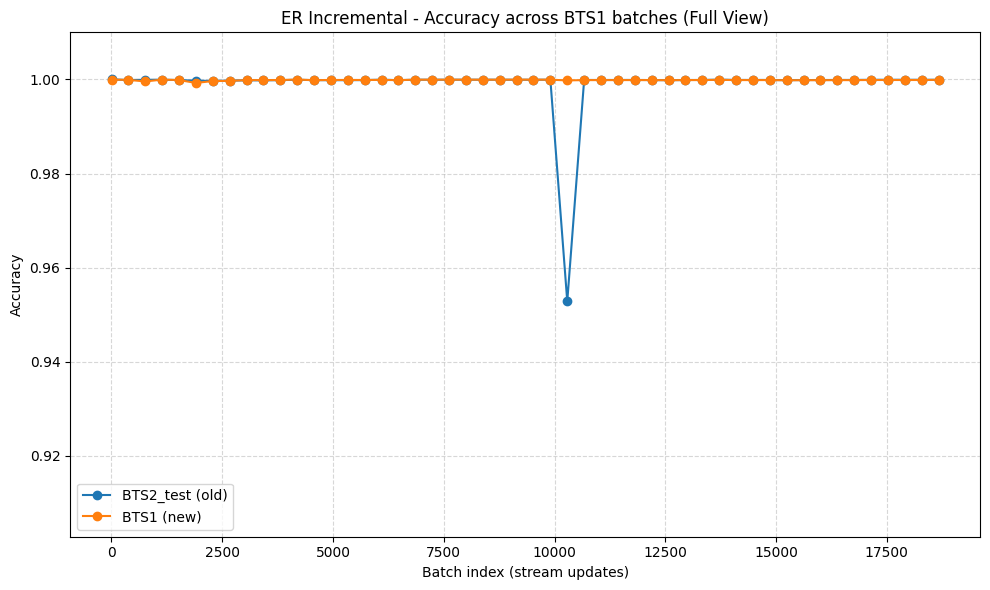

Saved full forgetting curve: ../outputs/ER_forgetting_curve_full.png


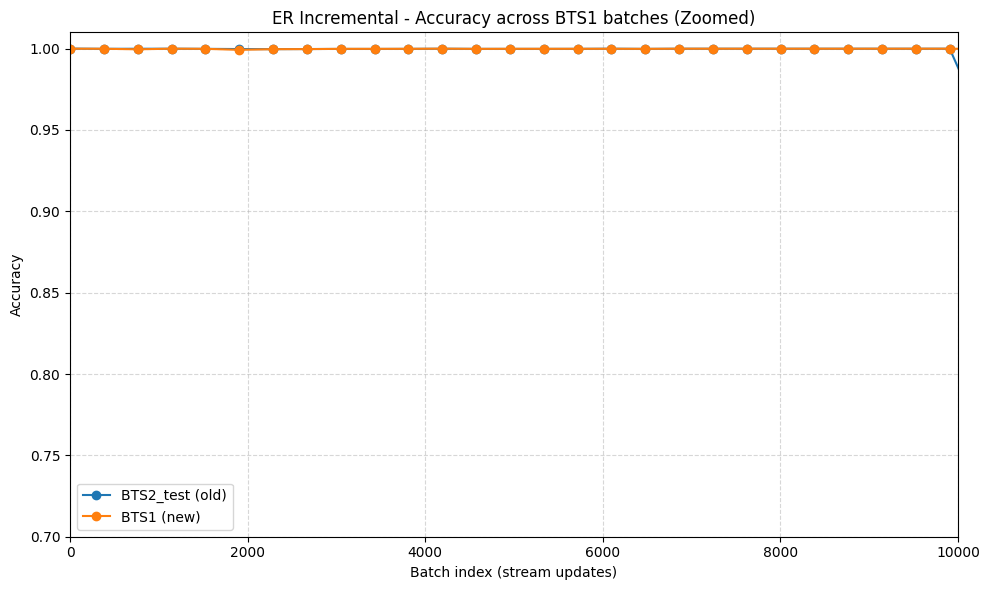

Saved zoomed forgetting curve: ../outputs/ER_forgetting_curve_zoom.png


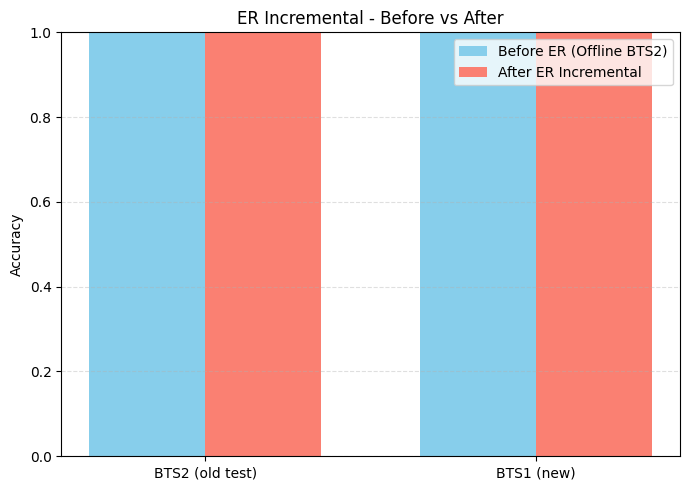

Saved before/after bar: ../outputs/ER_before_after.png
Saved metrics for ER to ../data/comparison_metrics.json.

=== ER Final Summary ===
  Initial (base) BTS2_test acc: 1.0000
  Final BTS2_test acc: 0.9999
  Final BTS1 acc: 0.9999
  AUROC: 1.0, F1: 0.9999, Forgetting Rate: 0.0001


In [3]:
# --- ER Experiment Execution ---

HIGH_LR = 5e-2 # Aggressive LR for the incremental phase
BATCH_SIZE = 128
lambda_label = "ER" # Identifier for file saving

# 1. Train Base Model on BTS2 (Offline)
print("\n=== ER Phase 1: Train Base Model on BTS2 (Offline) ===")
base_model = MLP(X_old.shape[1], hidden_size=16, output_dim=num_classes)
optimizer_base = optim.Adam(base_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

base_model = simple_train(base_model, X_old_train, y_old_train, optimizer_base, criterion, epochs=20)

acc_old_initial = evaluate_acc(base_model, X_old_test, y_old_test)
acc_new_initial = evaluate_acc(base_model, X_new, y_new_enc)
print(f"Initial BTS2_test: {acc_old_initial:.4f}, BTS1: {acc_new_initial:.4f}")

# 2. Setup Replay Buffer and Incremental Model
BUFFER_CAPACITY = int(X_old_train.shape[0] * 0.05) 
er_model = MLP(X_old.shape[1], hidden_size=16, output_dim=num_classes)
er_model.load_state_dict(base_model.state_dict())
optimizer_er = optim.Adam(er_model.parameters(), lr=HIGH_LR)
buffer = ReplayBuffer(BUFFER_CAPACITY, X_old.shape[1])
buffer.push(X_old_train, y_old_train) # Fill buffer with old task data
print(f"Replay buffer filled with initial data: {len(buffer.memory_X)} samples")

# Calculate evaluation interval
total_batches = ((X_new.shape[0] - 1)//BATCH_SIZE + 1) * 5
eval_interval = max(1, total_batches // 50) 
print(f"Total batches for 5 epochs: {total_batches}, Eval Interval: {eval_interval}")

# 3. Incremental Training
print("\n=== ER Phase 2: Incremental Training on BTS1 with Replay ===")
acc_old_batches, acc_new_batches, batch_idx = incremental_train_er_stream(
    er_model, X_new, y_new_enc, buffer,
    batch_size=BATCH_SIZE, epochs=5, optimizer=optimizer_er, criterion=criterion,
    X_old_test_local=X_old_test, y_old_test_local=y_old_test,
    X_new_val=X_new, y_new_val=y_new_enc, eval_interval=eval_interval
)

# 4. FINAL METRICS CALCULATION
acc_old_final = acc_old_batches[-1] if len(acc_old_batches) > 0 else evaluate_acc(er_model, X_old_test, y_old_test)
acc_new_final = acc_new_batches[-1] if len(acc_new_batches) > 0 else evaluate_acc(er_model, X_new, y_new_enc)
forgetting_rate = acc_old_initial - acc_old_final

# Calculate AUROC and F1 on combined (old_test + new)
X_comb = np.vstack([X_old_test, X_new])
y_comb = np.concatenate([y_old_test, y_new_enc])
probs_comb, preds_comb = predict_proba_and_pred(er_model, X_comb)

try:
    if num_classes == 2:
        auroc = roc_auc_score(y_comb, probs_comb[:,1])
    else:
        auroc = roc_auc_score(y_comb, probs_comb, multi_class='ovr', average='macro')
except Exception as e:
    print("AUROC calc failed:", e)
    auroc = float("nan")
f1 = f1_score(y_comb, preds_comb, average='weighted')

er_results = {
    "acc_old_initial": acc_old_initial,
    "acc_new_initial": acc_new_initial,
    "acc_old_final": float(round(acc_old_final, 4)),
    "acc_new_final": float(round(acc_new_final, 4)),
    "acc_old_batches": acc_old_batches,
    "acc_new_batches": acc_new_batches,
    "batch_idx": batch_idx,
    "AUROC": float(np.nan if np.isnan(auroc) else round(auroc,4)),
    "F1": float(round(f1,4)),
    "Forgetting_Rate": float(round(forgetting_rate,4))
}
res = er_results # Set 'res' for the plotting section

# Save ER model state
model_path = os.path.join(MODELS_DIR, "mlp_er.pth")
torch.save(er_model.state_dict(), model_path)
print(f"\nSaved ER model to {model_path}")


# 5. PLOTTING AND JSON SAVING

# A. Save Batch Accuracies CSV
df_acc = pd.DataFrame({
    "batch_idx": res["batch_idx"],
    "acc_bts2_test": res["acc_old_batches"],
    "acc_bts1": res["acc_new_batches"]
})
csv_path = os.path.join(OUT_DIR, f"{lambda_label}_batch_accuracies.csv")
df_acc.to_csv(csv_path, index=False)
print("Saved batch CSV:", csv_path)

# B. Plot Forgetting Curve (Full View)
plt.figure(figsize=(10,6))
plt.plot(res["batch_idx"], res["acc_old_batches"], '-o', label='BTS2_test (old)')
plt.plot(res["batch_idx"], res["acc_new_batches"], '-o', label='BTS1 (new)')
plt.xlabel("Batch index (stream updates)")
plt.ylabel("Accuracy")
plt.title(f"{lambda_label} Incremental - Accuracy across BTS1 batches (Full View)")

min_acc_overall = min(min(res["acc_old_batches"]), min(res["acc_new_batches"]))
y_min_plot = max(0.0, min_acc_overall - 0.05) 
plt.ylim(y_min_plot ,1.01) 

plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
curve_path = os.path.join(OUT_DIR, f"{lambda_label}_forgetting_curve_full.png")
plt.savefig(curve_path, dpi=200)
plt.show()
print("Saved full forgetting curve:", curve_path)

# C. Plot Forgetting Curve (Zoomed View)
plt.figure(figsize=(10,6))
plt.plot(res["batch_idx"], res["acc_old_batches"], '-o', label='BTS2_test (old)')
plt.plot(res["batch_idx"], res["acc_new_batches"], '-o', label='BTS1 (new)')
plt.xlabel("Batch index (stream updates)")
plt.ylabel("Accuracy")
plt.title(f"{lambda_label} Incremental - Accuracy across BTS1 batches (Zoomed)")

# Set Y-axis to clearly show the drops
plt.ylim(0.70, 1.01) 

# Set X-axis limits for the zoom. Adjusting to 0 to 10000 to catch initial volatility.
plt.xlim(0, 10000) 

plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
curve_path_zoom = os.path.join(OUT_DIR, f"{lambda_label}_forgetting_curve_zoom.png")
plt.savefig(curve_path_zoom, dpi=200)
plt.show()
print("Saved zoomed forgetting curve:", curve_path_zoom)

# D. Plot Before/After Bar
initial_old = res["acc_old_initial"]
initial_new = res["acc_new_initial"]
final_old = res["acc_old_final"]
final_new = res["acc_new_final"]

plt.figure(figsize=(7,5))
labels = ['BTS2 (old test)', 'BTS1 (new)']
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, [initial_old, initial_new], width, label='Before ER (Offline BTS2)', color='skyblue')
plt.bar(x + width/2, [final_old, final_new], width, label='After ER Incremental', color='salmon')
plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title(f"{lambda_label} Incremental - Before vs After")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
bar_path = os.path.join(OUT_DIR, f"{lambda_label}_before_after.png")
plt.savefig(bar_path, dpi=200)
plt.show()
print("Saved before/after bar:", bar_path)

# E. Save/Update JSON Metrics
key_name = lambda_label
try:
    with open(METRICS_FILE, 'r') as f:
        metrics_all = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    metrics_all = {}

metrics_all[key_name] = {
    "accuracy_data": {
        "BTS2 (Old)": res["acc_old_final"],
        "BTS1 (New)": res["acc_new_final"]
    },
    "metrics_data": {
        "AUROC": res["AUROC"],
        "F1-Score": res["F1"],
        "Forgetting Rate": res["Forgetting_Rate"]
    }
}

with open(METRICS_FILE, 'w') as f:
    json.dump(metrics_all, f, indent=4)

print(f"Saved metrics for {key_name} to {METRICS_FILE}.")


# 6. FINAL SUMMARY
print("\n=== ER Final Summary ===")
print(f"  Initial (base) BTS2_test acc: {er_results['acc_old_initial']:.4f}")
print(f"  Final BTS2_test acc: {er_results['acc_old_final']:.4f}")
print(f"  Final BTS1 acc: {er_results['acc_new_final']:.4f}")
print(f"  AUROC: {er_results['AUROC']}, F1: {er_results['F1']}, Forgetting Rate: {er_results['Forgetting_Rate']}")

